In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import datetime

In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
file_path = '/content/drive/MyDrive/TFM/DATOS CONJUNTOS CELTA TITULO J20.xlsx'

In [97]:
xls = pd.ExcelFile(file_path)

In [98]:
df = pd.read_excel('/content/drive/MyDrive/TFM/DATOS CONJUNTOS CELTA TITULO J20.xlsx', header=0)

In [99]:
print(xls.sheet_names)

['CELTA 24-25', 'JUGADORES 24-25', 'CELTA 23-24', 'JUGADORES 23-24']


In [100]:
celta_24_25 = pd.read_excel(xls, sheet_name="CELTA 24-25")
jugadores_24_25 = pd.read_excel(xls, sheet_name="JUGADORES 24-25")
celta_23_24 = pd.read_excel(xls, sheet_name="CELTA 23-24")
jugadores_23_24 = pd.read_excel(xls, sheet_name="JUGADORES 23-24")

In [101]:
print("CELTA 24-25")
display(celta_24_25.head())

print("JUGADORES 24-25")
display(jugadores_24_25.head())

print("CELTA 23-24")
display(celta_23_24.head())

print("JUGADORES 23-24")
display(jugadores_23_24.head())

CELTA 24-25


,Fecha,Hora,Jornada,Día,Sedes,Resultado,GF,GC,Adversario,Pos.,...,3.º cent.,3.º ataq.,Int,Tkl+Int,Bloqueos,Dis.1,Pases,Ganados,Perdidos,% de ganados
0,2024-08-16,19:00:00,1,Vie,Local,V,2,1,Alavés,63,...,10,2,11,29,5,3,2,12,6,66.7
1,2024-08-23,19:00:00,2,Vie,Local,V,3,1,Valencia,49,...,10,0,9,25,9,2,7,10,9,52.6
2,2024-08-26,21:30:00,3,Lun,Visitante,D,3,4,Villarreal,55,...,4,1,5,15,5,2,3,5,11,31.3
3,2024-09-01,17:00:00,4,Dom,Visitante,D,2,3,Osasuna,50,...,2,0,4,13,9,5,4,6,13,31.6
4,2024-09-15,14:00:00,5,Dom,Local,V,3,1,Valladolid,54,...,3,1,6,18,6,2,4,12,5,70.6


JUGADORES 24-25


,Jugador,País,Posc,Edad,PJ,Titular,Mín,90 s,Gls.,Ass,...,Gls./90,Ast/90,G+A/90,G-TP/90,G+A-TP/90,xG/90,xAG/90,xG+xAG/90,npxG/90,npxG+xAG/90
0,Óscar Mingueza,ESP,DFC,25,19,18,1.498,16.6,2,5,...,0.12,0.30,0.42,0.12,0.42,0.04,0.26,0.30,0.04,0.30
1,Carl Starfelt,SWE,DFC,29,18,16,1.446,16.1,1,0,...,0.06,0.00,0.06,0.06,0.06,0.02,0.01,0.03,0.02,0.03
2,Vicente Guaita,ESP,PO,38,16,16,1.440,16.0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,Fran Beltrán,ESP,CC,25,16,15,1.216,13.5,1,0,...,0.07,0.00,0.07,0.07,0.07,0.03,0.07,0.10,0.03,0.10
4,Hugo Álvarez,ESP,EXT,21,20,13,1.281,14.2,4,1,...,0.28,0.07,0.35,0.28,0.35,0.16,0.05,0.21,0.16,0.21


CELTA 23-24


,Fecha,Hora,Jornada,Día,Sedes,Res\nultado,GF,GC,Adversario,Pos.,...,3.º cent.,3.º ataq.,Int,Tkl+Int,Bloqueos,Dis.1,Pases,Ganados,Perdidos,% de ganados
0,2023-08-13,17:00:00,1,Dom,Local,D,0,2,Osasuna,53,...,4,0,11,19,14,1,13,15,15,50.0
1,2023-08-19,17:00:00,2,Sáb,Visitante,E,1,1,Real Sociedad,47,...,6,0,10,23,10,4,6,14,20,41.2
2,2023-08-25,21:30:00,3,Vie,Local,D,0,1,Real Madrid,37,...,6,2,7,22,6,2,4,11,8,57.9
3,2023-09-01,22:00:00,4,Vie,Visitante,V,3,2,Almería,37,...,8,2,9,27,8,3,5,8,15,34.8
4,2023-09-16,18:30:00,5,Sáb,Local,D,0,1,Mallorca,60,...,3,2,5,12,5,1,4,15,19,44.1


JUGADORES 23-24


,Jugador,País,Posc,Edad,PJ,Titular,Mín,90 s,Gls.,Ass,...,Gls./90,Ast/90,G+A/90,G-TP/90,G+A-TP/90,xG/90,xAG/90,xG+xAG/90,npxG/90,npxG+xAG/90
0,Jørgen Strand Larsen,NOR,DL,23,37,36,2.863,31.8,13,3,...,0.41,0.09,0.50,0.41,0.50,0.46,0.08,0.54,0.46,0.54
1,Óscar Mingueza,ESP,DFC,24,38,33,2.998,33.3,2,2,...,0.06,0.06,0.12,0.06,0.12,0.08,0.12,0.20,0.08,0.20
2,Unai Núñez,ESP,DFC,26,34,31,2.801,31.1,1,0,...,0.03,0.00,0.03,0.03,0.03,0.05,0.02,0.07,0.05,0.07
3,Iago Aspas,ESP,DL,35,35,31,2.707,30.1,9,10,...,0.30,0.33,0.63,0.20,0.53,0.38,0.34,0.72,0.25,0.59
4,Fran Beltrán,ESP,CC,24,33,28,2.428,27.0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.03,0.04,0.07,0.03,0.07


In [102]:
df.columns

Index([            'Fecha',              'Hora',           'Jornada',
                     'Día',             'Sedes',         'Resultado',
                      'GF',                'GC',        'Adversario',
                    'Pos.',        'Asistencia',           'Capitán',
               'Formación',           'Árbitro',                'TA',
                      'TR',       '2a amarilla',               'Fls',
                      'FR',                'PA',              'Gls.',
                     'Dis',               'DaP',           '% de TT',
                     'G/T',          'G/TalArc',              'Dist',
                      'FK',                'TP',             'TPint',
                      'xG',              'npxG',           'npxG/Sh',
                    'G-xG',           'np:G-xG',               'Cmp',
                    'Int.',             '% Cmp',        'Dist. tot.',
              'Dist. prg.',             'Cmp.1',            'Int..1',
                 '% 

In [103]:
print("Tamaño de cada dataset:")
print(f"CELTA 24-25: {celta_24_25.shape}")
print(f"JUGADORES 24-25: {jugadores_24_25.shape}")
print(f"CELTA 23-24: {celta_23_24.shape}")
print(f"JUGADORES 23-24: {jugadores_23_24.shape}")

Tamaño de cada dataset:
CELTA 24-25: (20, 70)
JUGADORES 24-25: (29, 33)
CELTA 23-24: (20, 70)
JUGADORES 23-24: (30, 33)


In [104]:
# Función para limpiar nombres de columnas
def clean_columns(df):
    df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()  # Quita espacios y pone en minúsculas
    return df

In [105]:
# Aplicar limpieza de nombres de columnas
celta_24_25 = clean_columns(celta_24_25)
jugadores_24_25 = clean_columns(jugadores_24_25)
celta_23_24 = clean_columns(celta_23_24)
jugadores_23_24 = clean_columns(jugadores_23_24)

In [106]:
# Eliminar columnas "Unnamed" si existen, asegurándonos de manejar valores NaN correctamente
celta_24_25 = celta_24_25.loc[:, ~celta_24_25.columns.str.contains("unnamed", case=False, na=False)]
jugadores_24_25 = jugadores_24_25.loc[:, ~jugadores_24_25.columns.str.contains("unnamed", case=False, na=False)]
celta_23_24 = celta_23_24.loc[:, ~celta_23_24.columns.str.contains("unnamed", case=False, na=False)]
jugadores_23_24 = jugadores_23_24.loc[:, ~jugadores_23_24.columns.str.contains("unnamed", case=False, na=False)]

In [107]:
# Convertir fechas al formato datetime si hay una columna de fecha
if 'fecha' in celta_24_25.columns:
    celta_24_25['fecha'] = pd.to_datetime(celta_24_25['fecha'], errors='coerce')
if 'fecha' in celta_23_24.columns:
    celta_23_24['fecha'] = pd.to_datetime(celta_23_24['fecha'], errors='coerce')

In [108]:
print("CELTA 24-25")
display(celta_24_25.head())

print("JUGADORES 24-25")
display(jugadores_24_25.head())

print("CELTA 23-24")
display(celta_23_24.head())

print("JUGADORES 23-24")
display(jugadores_23_24.head())

CELTA 24-25


,fecha,hora,jornada,día,sedes,resultado,gf,gc,adversario,pos.,...,3.º_cent.,3.º_ataq.,int,tkl+int,bloqueos,dis.1,pases,ganados,perdidos,%_de_ganados
0,2024-08-16,19:00:00,1,Vie,Local,V,2,1,Alavés,63,...,10,2,11,29,5,3,2,12,6,66.7
1,2024-08-23,19:00:00,2,Vie,Local,V,3,1,Valencia,49,...,10,0,9,25,9,2,7,10,9,52.6
2,2024-08-26,21:30:00,3,Lun,Visitante,D,3,4,Villarreal,55,...,4,1,5,15,5,2,3,5,11,31.3
3,2024-09-01,17:00:00,4,Dom,Visitante,D,2,3,Osasuna,50,...,2,0,4,13,9,5,4,6,13,31.6
4,2024-09-15,14:00:00,5,Dom,Local,V,3,1,Valladolid,54,...,3,1,6,18,6,2,4,12,5,70.6


JUGADORES 24-25


,jugador,país,posc,edad,pj,titular,mín,90_s,gls.,ass,...,gls./90,ast/90,g+a/90,g-tp/90,g+a-tp/90,xg/90,xag/90,xg+xag/90,npxg/90,npxg+xag/90
0,Óscar Mingueza,ESP,DFC,25,19,18,1.498,16.6,2,5,...,0.12,0.30,0.42,0.12,0.42,0.04,0.26,0.30,0.04,0.30
1,Carl Starfelt,SWE,DFC,29,18,16,1.446,16.1,1,0,...,0.06,0.00,0.06,0.06,0.06,0.02,0.01,0.03,0.02,0.03
2,Vicente Guaita,ESP,PO,38,16,16,1.440,16.0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,Fran Beltrán,ESP,CC,25,16,15,1.216,13.5,1,0,...,0.07,0.00,0.07,0.07,0.07,0.03,0.07,0.10,0.03,0.10
4,Hugo Álvarez,ESP,EXT,21,20,13,1.281,14.2,4,1,...,0.28,0.07,0.35,0.28,0.35,0.16,0.05,0.21,0.16,0.21


CELTA 23-24


,fecha,hora,jornada,día,sedes,res\nultado,gf,gc,adversario,pos.,...,3.º_cent.,3.º_ataq.,int,tkl+int,bloqueos,dis.1,pases,ganados,perdidos,%_de_ganados
0,2023-08-13,17:00:00,1,Dom,Local,D,0,2,Osasuna,53,...,4,0,11,19,14,1,13,15,15,50.0
1,2023-08-19,17:00:00,2,Sáb,Visitante,E,1,1,Real Sociedad,47,...,6,0,10,23,10,4,6,14,20,41.2
2,2023-08-25,21:30:00,3,Vie,Local,D,0,1,Real Madrid,37,...,6,2,7,22,6,2,4,11,8,57.9
3,2023-09-01,22:00:00,4,Vie,Visitante,V,3,2,Almería,37,...,8,2,9,27,8,3,5,8,15,34.8
4,2023-09-16,18:30:00,5,Sáb,Local,D,0,1,Mallorca,60,...,3,2,5,12,5,1,4,15,19,44.1


JUGADORES 23-24


,jugador,país,posc,edad,pj,titular,mín,90_s,gls.,ass,...,gls./90,ast/90,g+a/90,g-tp/90,g+a-tp/90,xg/90,xag/90,xg+xag/90,npxg/90,npxg+xag/90
0,Jørgen Strand Larsen,NOR,DL,23,37,36,2.863,31.8,13,3,...,0.41,0.09,0.50,0.41,0.50,0.46,0.08,0.54,0.46,0.54
1,Óscar Mingueza,ESP,DFC,24,38,33,2.998,33.3,2,2,...,0.06,0.06,0.12,0.06,0.12,0.08,0.12,0.20,0.08,0.20
2,Unai Núñez,ESP,DFC,26,34,31,2.801,31.1,1,0,...,0.03,0.00,0.03,0.03,0.03,0.05,0.02,0.07,0.05,0.07
3,Iago Aspas,ESP,DL,35,35,31,2.707,30.1,9,10,...,0.30,0.33,0.63,0.20,0.53,0.38,0.34,0.72,0.25,0.59
4,Fran Beltrán,ESP,CC,24,33,28,2.428,27.0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.03,0.04,0.07,0.03,0.07


In [109]:
# Revisar valores nulos en cada dataset
print("Valores nulos en CELTA 24-25:")
print(celta_24_25.isnull().sum())

print("Valores nulos en JUGADORES 24-25:")
print(jugadores_24_25.isnull().sum())

print("Valores nulos en CELTA 23-24:")
print(celta_23_24.isnull().sum())

print("Valores nulos en JUGADORES 23-24:")
print(jugadores_23_24.isnull().sum())

Valores nulos en CELTA 24-25:
fecha           0
hora            0
jornada         0
día             0
sedes           0
               ..
dis.1           0
pases           0
ganados         0
perdidos        0
%_de_ganados    0
Length: 70, dtype: int64
Valores nulos en JUGADORES 24-25:
jugador        0
país           0
posc           0
edad           0
pj             0
titular        0
mín            0
90_s           0
gls.           0
ass            0
g+a            0
g-tp           0
tp             0
tpint          0
ta             0
tr             0
xg             0
npxg           0
xag            0
npxg+xag       0
prgc           0
prgp           0
prgr           0
gls./90        0
ast/90         0
g+a/90         0
g-tp/90        0
g+a-tp/90      0
xg/90          0
xag/90         0
xg+xag/90      0
npxg/90        0
npxg+xag/90    0
dtype: int64
Valores nulos en CELTA 23-24:
fecha           0
hora            0
jornada         0
día             0
sedes           0
               ..
d

In [110]:
# Rellenamos los valores nulos con 0 en JUGADORES 23-24
jugadores_23_24.fillna(0, inplace=True)

In [111]:
# Comprobamos que ya no haya valores nulos
print("Valores nulos después de la corrección:")
print(jugadores_23_24.isnull().sum())

Valores nulos después de la corrección:
jugador        0
país           0
posc           0
edad           0
pj             0
titular        0
mín            0
90_s           0
gls.           0
ass            0
g+a            0
g-tp           0
tp             0
tpint          0
ta             0
tr             0
xg             0
npxg           0
xag            0
npxg+xag       0
prgc           0
prgp           0
prgr           0
gls./90        0
ast/90         0
g+a/90         0
g-tp/90        0
g+a-tp/90      0
xg/90          0
xag/90         0
xg+xag/90      0
npxg/90        0
npxg+xag/90    0
dtype: int64


In [112]:
print(celta_24_25.columns)

Index([       'fecha',         'hora',      'jornada',          'día',
              'sedes',    'resultado',           'gf',           'gc',
         'adversario',         'pos.',   'asistencia',      'capitán',
          'formación',      'árbitro',           'ta',           'tr',
        '2a_amarilla',          'fls',           'fr',           'pa',
               'gls.',          'dis',          'dap',      '%_de_tt',
                'g/t',     'g/talarc',         'dist',           'fk',
                 'tp',        'tpint',           'xg',         'npxg',
            'npxg/sh',         'g-xg',      'np:g-xg',          'cmp',
               'int.',        '%_cmp',   'dist._tot.',   'dist._prg.',
              'cmp.1',       'int..1',      '%_cmp.1',        'cmp.2',
             'int..2',      '%_cmp.2',        'cmp.3',       'int..3',
            '%_cmp.3',          'ass',          'xag',           'xa',
                 'pc',            nan,          'ppa',         'crap',
      

In [113]:
#  A nivel equipo
celta_24_25["dif_goles"] = celta_24_25["gf"] - celta_24_25["gc"]
celta_24_25["eficiencia_tiros"] = (celta_24_25["gf"] / celta_24_25["dis"]) * 100
celta_24_25["conversion_posesion"] = (celta_24_25["gf"] / celta_24_25["pos."]) * 100

In [114]:
#  A nivel jugador
jugadores_24_25["participacion_goles"] = ((jugadores_24_25["gls."] + jugadores_24_25["ass"]) / jugadores_24_25["mín"]) * 90
jugadores_24_25["rendimiento_xG"] = jugadores_24_25["gls."] - jugadores_24_25["xg"]

In [115]:
print(celta_24_25[["dif_goles", "eficiencia_tiros", "conversion_posesion"]].head())
print(jugadores_24_25[["participacion_goles", "rendimiento_xG"]].head())

   dif_goles  eficiencia_tiros  conversion_posesion
0          1         33.333333             3.174603
1          2         50.000000             6.122449
2         -1         15.000000             5.454545
3         -1         16.666667             4.000000
4          2         21.428571             5.555556
   participacion_goles  rendimiento_xG
0           420.560748             1.3
1            62.240664             0.7
2             0.000000             0.0
3            74.013158             0.6
4           351.288056             1.7


In [116]:
#  A nivel equipo
celta_23_24["dif_goles"] = celta_23_24["gf"] - celta_23_24["gc"]
celta_23_24["eficiencia_tiros"] = (celta_23_24["gf"] / celta_23_24["dis"]) * 100
celta_23_24["conversion_posesion"] = (celta_23_24["gf"] / celta_23_24["pos."]) * 100

In [117]:
#  A nivel jugador
jugadores_23_24["participacion_goles"] = ((jugadores_23_24["gls."] + jugadores_23_24["ass"]) / jugadores_23_24["mín"]) * 90
jugadores_23_24["rendimiento_xG"] = jugadores_23_24["gls."] - jugadores_23_24["xg"]

In [118]:
print(celta_23_24[["dif_goles", "eficiencia_tiros", "conversion_posesion"]].head())
print(jugadores_23_24[["participacion_goles", "rendimiento_xG"]].head())

   dif_goles  eficiencia_tiros  conversion_posesion
0         -2          0.000000             0.000000
1          0          5.882353             2.127660
2         -1          0.000000             0.000000
3          1         21.428571             8.108108
4         -1          0.000000             0.000000
   participacion_goles  rendimiento_xG
0           502.968914            -1.5
1           120.080053            -0.6
2            32.131382            -0.4
3           631.695604            -2.5
4             0.000000            -0.7


In [119]:
# Seleccionamos las métricas clave
metricas_clave = ["gf", "gc", "dif_goles", "eficiencia_tiros", "conversion_posesion", "xg", "npxg/sh", "pos."]

# Calculamos la media de cada métrica para cada temporada
estadisticas_24_25 = celta_24_25[metricas_clave].mean()
estadisticas_23_24 = celta_23_24[metricas_clave].mean()

# Creamos un DataFrame con la comparación
comparacion_estadisticas = pd.DataFrame({
    "2023-2024": estadisticas_23_24,
    "2024-2025": estadisticas_24_25
})

# Mostramos la comparación
print(comparacion_estadisticas)

                     2023-2024  2024-2025
gf                    1.050000   1.450000
gc                    1.500000   1.600000
dif_goles            -0.450000  -0.150000
eficiencia_tiros      7.900064  17.207526
conversion_posesion   2.574860   2.871372
xg                    1.365000   1.420000
npxg/sh               0.094500   0.129500
pos.                 44.100000  53.400000


In [120]:
# Seleccionamos las métricas clave individuales
metricas_jugadores = ["participacion_goles", "rendimiento_xG"]

# Calculamos las medias de cada métrica por temporada
jugadores_24_25_mean = jugadores_24_25[metricas_jugadores].mean()
jugadores_23_24_mean = jugadores_23_24[metricas_jugadores].mean()

# Creamos un DataFrame con la comparación
comparacion_jugadores = pd.DataFrame({
    "2023-2024": jugadores_23_24_mean,
    "2024-2025": jugadores_24_25_mean
})

# Mostramos la comparación
print(comparacion_jugadores)

                     2023-2024  2024-2025
participacion_goles  68.066555  76.632172
rendimiento_xG       -0.220000  -0.027586


In [121]:
# Asegurar que la columna "jugador" sea el índice en ambos dataframes
jugadores_23_24 = jugadores_23_24.set_index("jugador")
jugadores_24_25 = jugadores_24_25.set_index("jugador")

# Definir las métricas clave a comparar
metricas_comparacion = [col for col in jugadores_23_24.columns if "/90" in col]

# Filtrar solo los jugadores que han estado en ambas temporadas
jugadores_comunes = jugadores_23_24.index.intersection(jugadores_24_25.index)
jugadores_23_24_filtrado = jugadores_23_24.loc[jugadores_comunes]
jugadores_24_25_filtrado = jugadores_24_25.loc[jugadores_comunes]

# Comparar los valores entre temporadas
comparacion_jugadores = jugadores_24_25_filtrado[metricas_comparacion] - jugadores_23_24_filtrado[metricas_comparacion]

# Mostrar los jugadores con mayor mejora y mayor bajón en cada métrica
for metrica in metricas_comparacion:
    print(f"\n📊 Jugadores con mayor mejora en {metrica}:")
    print(comparacion_jugadores[metrica].sort_values(ascending=False).head(3))

    print(f"\n📉 Jugadores con mayor bajón en {metrica}:")
    print(comparacion_jugadores[metrica].sort_values(ascending=True).head(3))


📊 Jugadores con mayor mejora en gls./90:
jugador
Hugo Álvarez    0.16
Iago Aspas      0.15
Fran Beltrán    0.07
Name: gls./90, dtype: float64

📉 Jugadores con mayor bajón en gls./90:
jugador
Williot Swedberg      -0.79
Anastasios Douvikas   -0.29
Tadeo Allende         -0.27
Name: gls./90, dtype: float64

📊 Jugadores con mayor mejora en ast/90:
jugador
Williot Swedberg       0.37
Óscar Mingueza         0.24
Anastasios Douvikas    0.04
Name: ast/90, dtype: float64

📉 Jugadores con mayor bajón en ast/90:
jugador
Damián Rodríguez   -0.70
Luca de la Torre   -0.18
Franco Cervi       -0.16
Name: ast/90, dtype: float64

📊 Jugadores con mayor mejora en g+a/90:
jugador
Óscar Mingueza    0.30
Hugo Álvarez      0.11
Fran Beltrán      0.07
Name: g+a/90, dtype: float64

📉 Jugadores con mayor bajón en g+a/90:
jugador
Damián Rodríguez   -0.70
Williot Swedberg   -0.42
Tadeo Allende      -0.27
Name: g+a/90, dtype: float64

📊 Jugadores con mayor mejora en g-tp/90:
jugador
Hugo Álvarez    0.16
Iago Aspas

In [122]:
# Verificar nombres de columnas y unificarlos
jugadores_23_24.columns = jugadores_23_24.columns.str.lower().str.strip()
jugadores_24_25.columns = jugadores_24_25.columns.str.lower().str.strip()

In [123]:
# Asegurar que "jugador" es el índice
if "jugador" in jugadores_23_24.columns and "jugador" in jugadores_24_25.columns:
    jugadores_23_24 = jugadores_23_24.set_index("jugador")
    jugadores_24_25 = jugadores_24_25.set_index("jugador")

# Identificar métricas normalizadas por 90 minutos
metricas_90 = [col for col in jugadores_23_24.columns if "/90" in col]

# Filtrar solo los jugadores que han estado en ambas temporadas
jugadores_comunes = jugadores_23_24.index.intersection(jugadores_24_25.index)
jugadores_23_24_filtrado = jugadores_23_24.loc[jugadores_comunes]
jugadores_24_25_filtrado = jugadores_24_25.loc[jugadores_comunes]

# Comparar métricas ofensivas entre temporadas
dif_metricas_90 = jugadores_24_25_filtrado[metricas_90] - jugadores_23_24_filtrado[metricas_90]

# Goles, Asistencias y G+A
for metrica in ["gls./90", "ast/90", "g+a/90"]:
    print(f"\n📊 Jugadores con mayor mejora en {metrica}:")
    print(dif_metricas_90[metrica].sort_values(ascending=False).head(3))
    print(f"\n📉 Jugadores con mayor bajón en {metrica}:")
    print(dif_metricas_90[metrica].sort_values(ascending=True).head(3))


📊 Jugadores con mayor mejora en gls./90:
jugador
Hugo Álvarez    0.16
Iago Aspas      0.15
Fran Beltrán    0.07
Name: gls./90, dtype: float64

📉 Jugadores con mayor bajón en gls./90:
jugador
Williot Swedberg      -0.79
Anastasios Douvikas   -0.29
Tadeo Allende         -0.27
Name: gls./90, dtype: float64

📊 Jugadores con mayor mejora en ast/90:
jugador
Williot Swedberg       0.37
Óscar Mingueza         0.24
Anastasios Douvikas    0.04
Name: ast/90, dtype: float64

📉 Jugadores con mayor bajón en ast/90:
jugador
Damián Rodríguez   -0.70
Luca de la Torre   -0.18
Franco Cervi       -0.16
Name: ast/90, dtype: float64

📊 Jugadores con mayor mejora en g+a/90:
jugador
Óscar Mingueza    0.30
Hugo Álvarez      0.11
Fran Beltrán      0.07
Name: g+a/90, dtype: float64

📉 Jugadores con mayor bajón en g+a/90:
jugador
Damián Rodríguez   -0.70
Williot Swedberg   -0.42
Tadeo Allende      -0.27
Name: g+a/90, dtype: float64


In [124]:
# xG, xAG, xG+xAG
for metrica in ["xg/90", "xag/90", "xg+xag/90"]:
    print(f"\n📊 Jugadores con mayor mejora en {metrica}:")
    print(dif_metricas_90[metrica].sort_values(ascending=False).head(3))
    print(f"\n📉 Jugadores con mayor bajón en {metrica}:")
    print(dif_metricas_90[metrica].sort_values(ascending=True).head(3))


📊 Jugadores con mayor mejora en xg/90:
jugador
Anastasios Douvikas    0.15
Hugo Álvarez           0.04
Iago Aspas             0.04
Name: xg/90, dtype: float64

📉 Jugadores con mayor bajón en xg/90:
jugador
Tadeo Allende      -0.33
Luca de la Torre   -0.11
Franco Cervi       -0.08
Name: xg/90, dtype: float64

📊 Jugadores con mayor mejora en xag/90:
jugador
Williot Swedberg    0.19
Óscar Mingueza      0.14
Fran Beltrán        0.03
Name: xag/90, dtype: float64

📉 Jugadores con mayor bajón en xag/90:
jugador
Damián Rodríguez   -0.19
Franco Cervi       -0.14
Iago Aspas         -0.13
Name: xag/90, dtype: float64

📊 Jugadores con mayor mejora en xg+xag/90:
jugador
Williot Swedberg       0.20
Óscar Mingueza         0.10
Anastasios Douvikas    0.05
Name: xg+xag/90, dtype: float64

📉 Jugadores con mayor bajón en xg+xag/90:
jugador
Tadeo Allende      -0.43
Franco Cervi       -0.21
Damián Rodríguez   -0.20
Name: xg+xag/90, dtype: float64


In [125]:
# % Conversión de tiros
jugadores_23_24_filtrado["% conversion tiros"] = jugadores_23_24_filtrado["gls./90"] / jugadores_23_24_filtrado["xg/90"]
jugadores_24_25_filtrado["% conversion tiros"] = jugadores_24_25_filtrado["gls./90"] / jugadores_24_25_filtrado["xg/90"]

dif_conversion = jugadores_24_25_filtrado["% conversion tiros"] - jugadores_23_24_filtrado["% conversion tiros"]
print("\n📊 Jugadores con mayor mejora en % conversión de tiros:")
print(dif_conversion.sort_values(ascending=False).head(3))
print("\n📉 Jugadores con mayor bajón en % conversión de tiros:")
print(dif_conversion.sort_values(ascending=True).head(3))


📊 Jugadores con mayor mejora en % conversión de tiros:
jugador
Fran Beltrán      2.333333
Carl Starfelt     2.333333
Óscar Mingueza    2.250000
Name: % conversion tiros, dtype: float64

📉 Jugadores con mayor bajón en % conversión de tiros:
jugador
Williot Swedberg      -1.680851
Jonathan Bamba        -1.000000
Anastasios Douvikas   -0.849608
Name: % conversion tiros, dtype: float64


In [126]:
# Cargar datos del equipo desde las hojas "Celta 23-24" y "Celta 24-25"
celta_23_24 = pd.read_excel("/content/drive/MyDrive/TFM/DATOS CONJUNTOS CELTA TITULO J20.xlsx", sheet_name="CELTA 23-24")
celta_24_25 = pd.read_excel("/content/drive/MyDrive/TFM/DATOS CONJUNTOS CELTA TITULO J20.xlsx", sheet_name="CELTA 24-25")

# Asegurar que las columnas tienen un formato consistente
celta_23_24.columns = celta_23_24.columns.str.lower().str.strip()
celta_24_25.columns = celta_24_25.columns.str.lower().str.strip()


In [127]:
# Seleccionar métricas clave
metricas = ["gls.", "ass", "xg", "xag", "pos."]

# Filtrar las métricas de cada temporada
datos_23_24 = celta_23_24[metricas].sum()
datos_24_25 = celta_24_25[metricas].sum()

# Calcular diferencias
dif_metricas = datos_24_25 - datos_23_24

# Mostrar resultados
print("\n📊 Comparación de Goles, Asistencias, xG, xAG y Posesión entre temporadas:")
for metrica in metricas:
    cambio = dif_metricas[metrica]
    signo = "+" if cambio > 0 else ""
    print(f"{metrica.upper()}: {datos_24_25[metrica]} ({signo}{cambio} respecto a 23/24)")



📊 Comparación de Goles, Asistencias, xG, xAG y Posesión entre temporadas:
GLS.: 28.0 (+8.0 respecto a 23/24)
ASS: 19.0 (+7.0 respecto a 23/24)
XG: 28.400000000000002 (+1.1000000000000014 respecto a 23/24)
XAG: 21.500000000000004 (+2.700000000000003 respecto a 23/24)
POS.: 1068.0 (+186.0 respecto a 23/24)


In [128]:
# Seleccionar solo las métricas de interés (valores totales de la temporada)
metricas_pases = ["pc", "prgp"]

# Extraer valores totales de pases clave (pc) y pases progresivos (prgp)
pc_23_24, prgp_23_24 = celta_23_24[metricas_pases].sum()
pc_24_25, prgp_24_25 = celta_24_25[metricas_pases].sum()

# Calcular la diferencia entre temporadas
dif_pc = pc_24_25 - pc_23_24
dif_prgp = prgp_24_25 - prgp_23_24

# Mostrar resultados
print("\n📊 Comparación de Pases Clave y Pases Progresivos entre temporadas:")
print(f"Pases Clave (PC): {pc_24_25} ({'+' if dif_pc > 0 else ''}{dif_pc} respecto a 23/24)")
print(f"Pases Progresivos (PRGP): {prgp_24_25} ({'+' if dif_prgp > 0 else ''}{dif_prgp} respecto a 23/24)")


📊 Comparación de Pases Clave y Pases Progresivos entre temporadas:
Pases Clave (PC): 175 (-27 respecto a 23/24)
Pases Progresivos (PRGP): 784 (+105 respecto a 23/24)


In [129]:
# Cargar datos del equipo desde las hojas "Celta 23-24" y "Celta 24-25"
celta_23_24 = pd.read_excel("/content/drive/MyDrive/TFM/DATOS CONJUNTOS CELTA TITULO J20.xlsx", sheet_name="CELTA 23-24")
celta_24_25 = pd.read_excel("/content/drive/MyDrive/TFM/DATOS CONJUNTOS CELTA TITULO J20.xlsx", sheet_name="CELTA 24-25")

# Asegurar que las columnas tienen un formato consistente
celta_23_24.columns = celta_23_24.columns.str.lower().str.strip()
celta_24_25.columns = celta_24_25.columns.str.lower().str.strip()

# Seleccionar métricas relevantes
metricas = ["gls.", "dis", "dap", "% de tt"]

# Filtrar las métricas de cada temporada
datos_23_24 = celta_23_24[metricas].sum()
datos_24_25 = celta_24_25[metricas].sum()

# Calcular diferencias
dif_metricas = datos_24_25 - datos_23_24

# Mostrar resultados
print("\n📊 Comparación de Goles, Disparos y Eficiencia de Conversión entre temporadas:")
for metrica in metricas:
    print(f"{metrica.upper()}: {datos_24_25[metrica]} ({'+' if dif_metricas[metrica] >= 0 else ''}{dif_metricas[metrica]} respecto a 23/24)")



📊 Comparación de Goles, Disparos y Eficiencia de Conversión entre temporadas:
GLS.: 28.0 (+8.0 respecto a 23/24)
DIS: 231.0 (-37.0 respecto a 23/24)
DAP: 84.0 (+6.0 respecto a 23/24)
% DE TT: 777.2 (+184.10000000000014 respecto a 23/24)


In [130]:
# Filtrar los datos según localía
casa_23_24 = celta_23_24[celta_23_24["sedes"] == "Local"]
fuera_23_24 = celta_23_24[celta_23_24["sedes"] == "Visitante"]

casa_24_25 = celta_24_25[celta_24_25["sedes"] == "Local"]
fuera_24_25 = celta_24_25[celta_24_25["sedes"] == "Visitante"]

# Sumar métricas ofensivas para cada temporada y localía
estadisticas_casa = casa_24_25[["gls.", "ass", "dis", "dap", "xg", "xag"]].sum() - casa_23_24[["gls.", "ass", "dis", "dap", "xg", "xag"]].sum()
estadisticas_fuera = fuera_24_25[["gls.", "ass", "dis", "dap", "xg", "xag"]].sum() - fuera_23_24[["gls.", "ass", "dis", "dap", "xg", "xag"]].sum()

# Mostrar resultados
print("📊 Comparación de Producción Ofensiva en Casa:")
print(estadisticas_casa)

print("\n📊 Comparación de Producción Ofensiva Fuera de Casa:")
print(estadisticas_fuera)

📊 Comparación de Producción Ofensiva en Casa:
gls.    11.0
ass     11.0
dis    -47.0
dap     12.0
xg      -1.8
xag      1.0
dtype: float64

📊 Comparación de Producción Ofensiva Fuera de Casa:
gls.    -3.0
ass     -4.0
dis     10.0
dap     -6.0
xg       2.9
xag      1.7
dtype: float64


In [131]:
# Crear una nueva columna 'mes' a partir de la fecha
celta_23_24["mes"] = celta_23_24["fecha"].dt.month
celta_24_25["mes"] = celta_24_25["fecha"].dt.month

In [132]:
# Agrupar por mes y sumar las métricas clave
rendimiento_mensual_23_24 = celta_23_24.groupby("mes")[["gls.", "ass", "dis", "dap", "xg", "xag"]].sum()
rendimiento_mensual_24_25 = celta_24_25.groupby("mes")[["gls.", "ass", "dis", "dap", "xg", "xag"]].sum()

# Calcular la diferencia entre temporadas
dif_rendimiento_mensual = rendimiento_mensual_24_25 - rendimiento_mensual_23_24

# Mostrar resultados
print("📊 Comparación de rendimiento mensual entre temporadas:")
print(dif_rendimiento_mensual)

📊 Comparación de rendimiento mensual entre temporadas:
     gls.  ass  dis  dap   xg  xag
mes                               
1      -1    0    2    1 -0.6  0.2
8       7    5   -9    5  1.6  0.7
9       1    0    7    4  1.9  0.5
10     -1    0  -17   -7 -2.2 -0.8
11      2    0    3    6  2.2  2.7
12      0    2  -23   -3 -1.8 -0.6


In [133]:
# Calcular la correlación entre posesión y xG
correlacion_23_24 = celta_23_24["pos."].corr(celta_23_24["xg"])
correlacion_24_25 = celta_24_25["pos."].corr(celta_24_25["xg"])

print(f"📊 Correlación Posesión - xG en 23/24: {correlacion_23_24:.2f}")
print(f"📊 Correlación Posesión - xG en 24/25: {correlacion_24_25:.2f}")

📊 Correlación Posesión - xG en 23/24: 0.42
📊 Correlación Posesión - xG en 24/25: -0.07


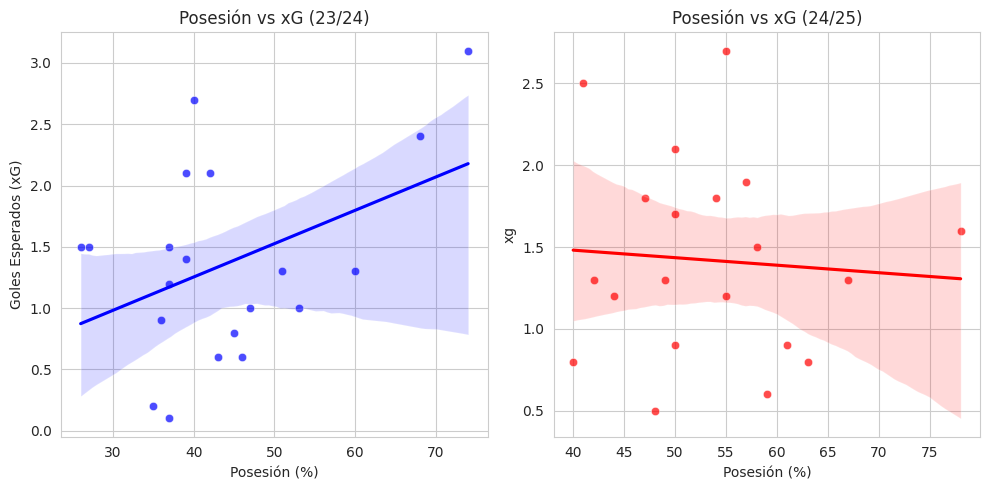

In [134]:
# Visualización de la relación entre posesión y xG
plt.figure(figsize=(10, 5))

# Temporada 23/24
plt.subplot(1, 2, 1)
sns.scatterplot(x=celta_23_24["pos."], y=celta_23_24["xg"], color="blue", alpha=0.7)
sns.regplot(x=celta_23_24["pos."], y=celta_23_24["xg"], scatter=False, color="blue")
plt.title("Posesión vs xG (23/24)")
plt.xlabel("Posesión (%)")
plt.ylabel("Goles Esperados (xG)")

# Temporada 24/25
plt.subplot(1, 2, 2)
sns.scatterplot(x=celta_24_25["pos."], y=celta_24_25["xg"], color="red", alpha=0.7)
sns.regplot(x=celta_24_25["pos."], y=celta_24_25["xg"], scatter=False, color="red")
plt.title("Posesión vs xG (24/25)")
plt.xlabel("Posesión (%)")

plt.tight_layout()
plt.show()

In [135]:
# Calcular métricas de calidad de los tiros
celta_23_24["xG_por_DIS"] = celta_23_24["xg"] / celta_23_24["dis"]
celta_24_25["xG_por_DIS"] = celta_24_25["xg"] / celta_24_25["dis"]

celta_23_24["%_DAP_DIS"] = (celta_23_24["dap"] / celta_23_24["dis"]) * 100
celta_24_25["%_DAP_DIS"] = (celta_24_25["dap"] / celta_24_25["dis"]) * 100

# Calcular medias
calidad_tiros = pd.DataFrame({
    "Métrica": ["xG por DIS", "% de DAP/DIS"],
    "23/24": [celta_23_24["xG_por_DIS"].mean(), celta_23_24["%_DAP_DIS"].mean()],
    "24/25": [celta_24_25["xG_por_DIS"].mean(), celta_24_25["%_DAP_DIS"].mean()]
})

print("📊 Comparación de Calidad de los Tiros:")
print(calidad_tiros)


📊 Comparación de Calidad de los Tiros:
        Métrica      23/24      24/25
0    xG por DIS   0.097261   0.141659
1  % de DAP/DIS  29.651118  38.854809


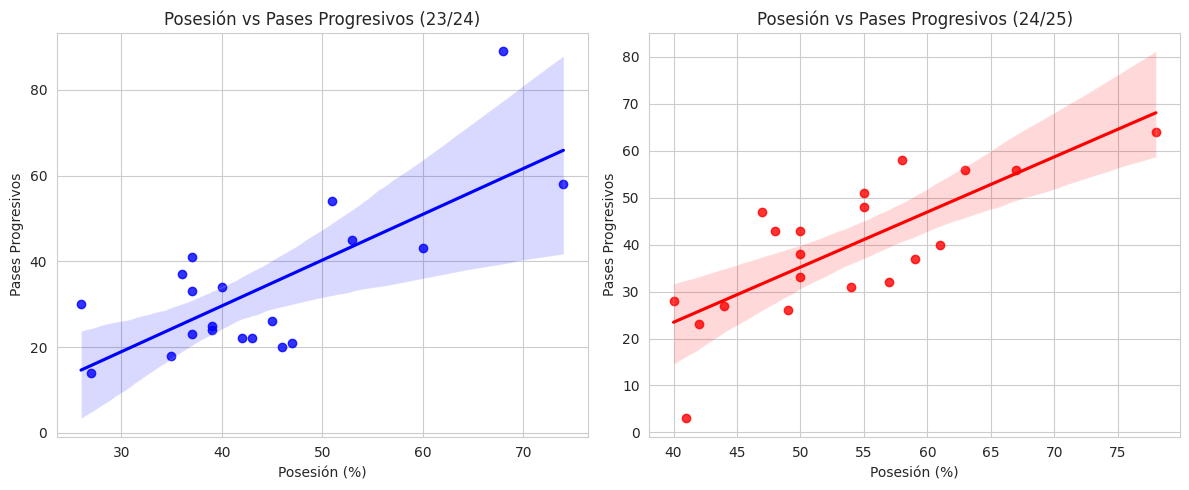

In [136]:
# Relación entre posesión y pases progresivos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(x=celta_23_24["pos."], y=celta_23_24["prgp"], ax=axes[0], color="blue")
axes[0].set_title("Posesión vs Pases Progresivos (23/24)")
axes[0].set_xlabel("Posesión (%)")
axes[0].set_ylabel("Pases Progresivos")

sns.regplot(x=celta_24_25["pos."], y=celta_24_25["prgp"], ax=axes[1], color="red")
axes[1].set_title("Posesión vs Pases Progresivos (24/25)")
axes[1].set_xlabel("Posesión (%)")
axes[1].set_ylabel("Pases Progresivos")

plt.tight_layout()
plt.show()


In [137]:
# Calcular correlaciones
correlacion_23_24 = celta_23_24["pos."].corr(celta_23_24["prgp"])
correlacion_24_25 = celta_24_25["pos."].corr(celta_24_25["prgp"])

print(f"📊 Correlación Posesión - PRGP en 23/24: {correlacion_23_24:.2f}")
print(f"📊 Correlación Posesión - PRGP en 24/25: {correlacion_24_25:.2f}")

📊 Correlación Posesión - PRGP en 23/24: 0.74
📊 Correlación Posesión - PRGP en 24/25: 0.76


In [138]:
def obtener_defensores(formacion):
    """Extrae el número de defensores de la formación táctico-numérica"""
    return int(formacion.split('-')[1])  # Segundo número indica defensores

# Extraer el número de defensores para cada partido
for df in [celta_23_24, celta_24_25]:
    df['defensores'] = df['formación'].astype(str).apply(obtener_defensores)

In [139]:
# Filtrar por formaciones con defensa de 4 y defensa de 3
defensa_4_23_24 = celta_23_24[celta_23_24['defensores'] == 4]
defensa_3_23_24 = celta_23_24[celta_23_24['defensores'] == 3]

defensa_4_24_25 = celta_24_25[celta_24_25['defensores'] == 4]
defensa_3_24_25 = celta_24_25[celta_24_25['defensores'] == 3]

In [140]:
# Calcular promedios de goles y xG por partido en cada sistema
def calcular_promedios(df):
    return {
        'Goles Promedio': df['gls.'].mean(),
        'xG Promedio': df['xg'].mean()
    }

promedios_4_23_24 = calcular_promedios(defensa_4_23_24)
promedios_3_23_24 = calcular_promedios(defensa_3_23_24)

promedios_4_24_25 = calcular_promedios(defensa_4_24_25)
promedios_3_24_25 = calcular_promedios(defensa_3_24_25)

# Mostrar resultados
print("📊 Comparación de Eficiencia Ofensiva por Formación:")
print("\nTemporada 23/24:")
print(f"Defensa de 4: {promedios_4_23_24}")
print(f"Defensa de 3: {promedios_3_23_24}")

print("\nTemporada 24/25:")
print(f"Defensa de 4: {promedios_4_24_25}")
print(f"Defensa de 3: {promedios_3_24_25}")

📊 Comparación de Eficiencia Ofensiva por Formación:

Temporada 23/24:
Defensa de 4: {'Goles Promedio': 1.0, 'xG Promedio': 1.4692307692307693}
Defensa de 3: {'Goles Promedio': 0.0, 'xG Promedio': 1.3}

Temporada 24/25:
Defensa de 4: {'Goles Promedio': 1.5, 'xG Promedio': 2.3}
Defensa de 3: {'Goles Promedio': 1.3888888888888888, 'xG Promedio': 1.3222222222222222}


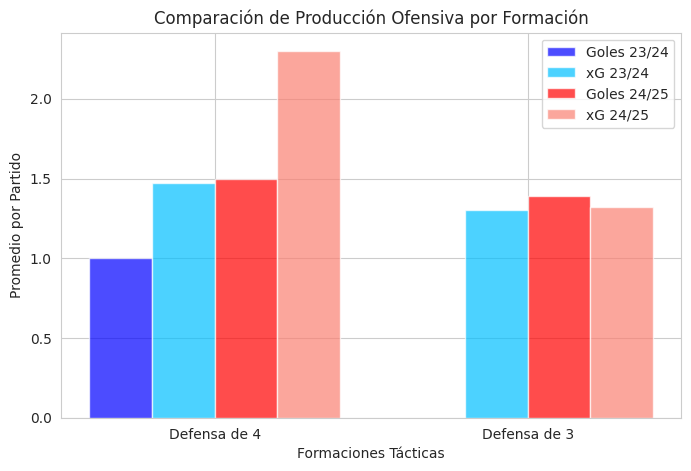

In [141]:

# Datos obtenidos
formaciones = ["Defensa de 4", "Defensa de 3"]

goles_23_24 = [1.0, 0.0]
xg_23_24 = [1.47, 1.3]

goles_24_25 = [1.5, 1.39]
xg_24_25 = [2.3, 1.32]

# Configuración del gráfico
x = np.arange(len(formaciones))
width = 0.2

fig, ax = plt.subplots(figsize=(8,5))

# Barras para cada temporada
bars1 = ax.bar(x - width, goles_23_24, width, label="Goles 23/24", color="blue", alpha=0.7)
bars2 = ax.bar(x, xg_23_24, width, label="xG 23/24", color="deepskyblue", alpha=0.7)

bars3 = ax.bar(x + width, goles_24_25, width, label="Goles 24/25", color="red", alpha=0.7)
bars4 = ax.bar(x + 2*width, xg_24_25, width, label="xG 24/25", color="salmon", alpha=0.7)

# Etiquetas y formato
ax.set_xlabel("Formaciones Tácticas")
ax.set_ylabel("Promedio por Partido")
ax.set_title("Comparación de Producción Ofensiva por Formación")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(formaciones)
ax.legend()

plt.show()

In [142]:
# Calcular promedios de pases por tipo
pases_23_24 = {
    "Pases Cortos": [celta_23_24["cmp.1"].mean(), celta_23_24["int..1"].mean(), celta_23_24["% cmp.1"].mean()],
    "Pases Medios": [celta_23_24["cmp.2"].mean(), celta_23_24["int..2"].mean(), celta_23_24["% cmp.2"].mean()],
    "Pases Largos": [celta_23_24["cmp.3"].mean(), celta_23_24["int..3"].mean(), celta_23_24["% cmp.3"].mean()]
}

pases_24_25 = {
    "Pases Cortos": [celta_24_25["cmp.1"].mean(), celta_24_25["int..1"].mean(), celta_24_25["% cmp.1"].mean()],
    "Pases Medios": [celta_24_25["cmp.2"].mean(), celta_24_25["int..2"].mean(), celta_24_25["% cmp.2"].mean()],
    "Pases Largos": [celta_24_25["cmp.3"].mean(), celta_24_25["int..3"].mean(), celta_24_25["% cmp.3"].mean()]
}

In [143]:
# Convertir a DataFrame
df_pases_23_24 = pd.DataFrame(pases_23_24, index=["Pases Completados", "Pases Intentados", "Precisión (%)"])
df_pases_24_25 = pd.DataFrame(pases_24_25, index=["Pases Completados", "Pases Intentados", "Precisión (%)"])

# Unir en un solo DataFrame para comparación
df_pases = pd.concat([df_pases_23_24.T, df_pases_24_25.T], keys=["23/24", "24/25"])
df_pases = df_pases.reset_index().rename(columns={"level_0": "Temporada", "level_1": "Tipo de Pase"})

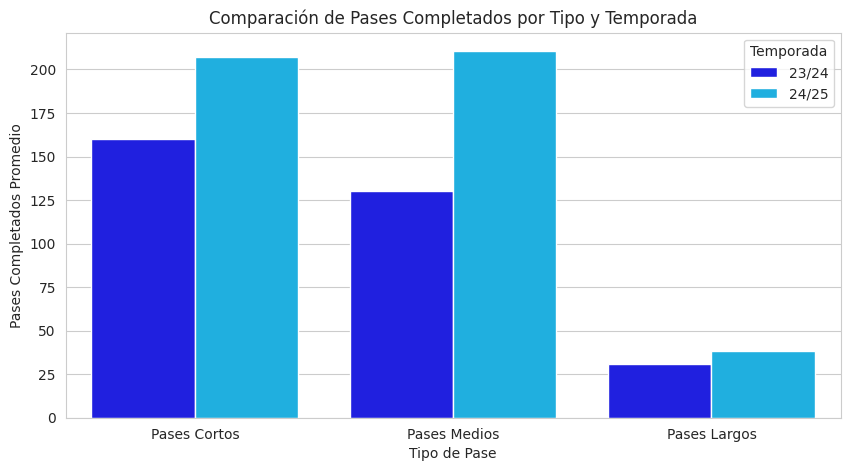

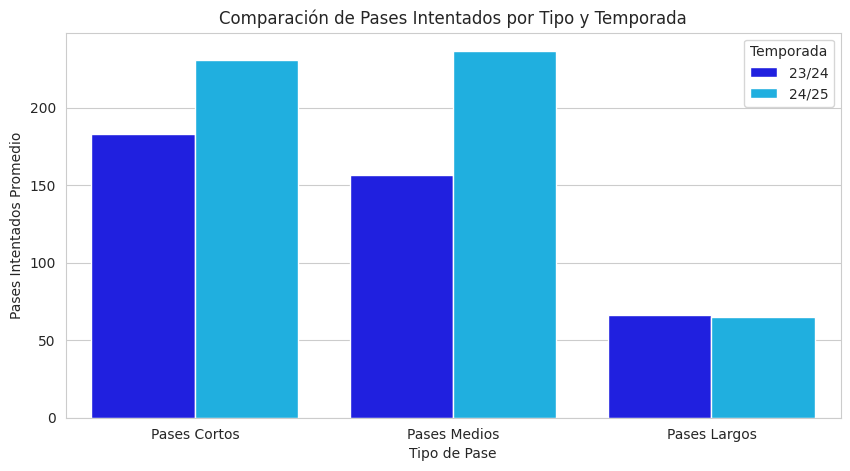

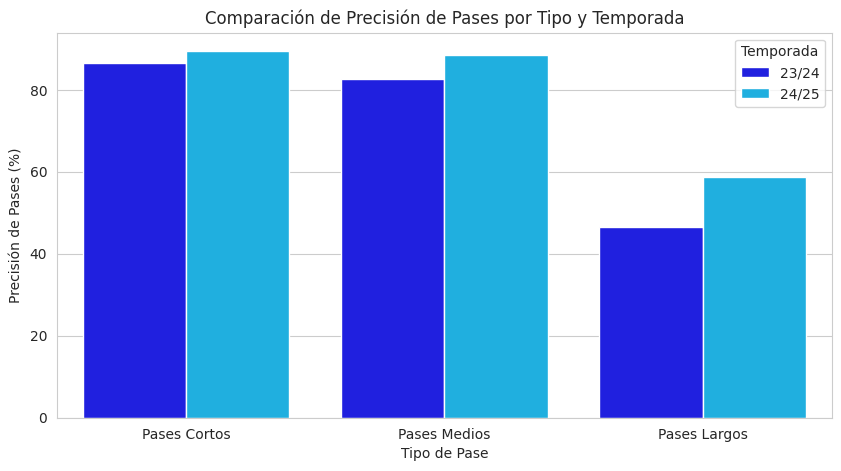

In [144]:
# Configuración de estilo para los gráficos
sns.set_style("whitegrid")

# 📊 Gráfico de Pases Completados
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pases, x="Tipo de Pase", y="Pases Completados", hue="Temporada", palette=["blue", "deepskyblue"])
plt.xlabel("Tipo de Pase")
plt.ylabel("Pases Completados Promedio")
plt.title("Comparación de Pases Completados por Tipo y Temporada")
plt.legend(title="Temporada")
plt.show()

# 📊 Gráfico de Pases Intentados
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pases, x="Tipo de Pase", y="Pases Intentados", hue="Temporada", palette=["blue", "deepskyblue"])
plt.xlabel("Tipo de Pase")
plt.ylabel("Pases Intentados Promedio")
plt.title("Comparación de Pases Intentados por Tipo y Temporada")
plt.legend(title="Temporada")
plt.show()

# 📊 Gráfico de Precisión de Pases
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pases, x="Tipo de Pase", y="Precisión (%)", hue="Temporada", palette=["blue", "deepskyblue"])
plt.xlabel("Tipo de Pase")
plt.ylabel("Precisión de Pases (%)")
plt.title("Comparación de Precisión de Pases por Tipo y Temporada")
plt.legend(title="Temporada")
plt.show()

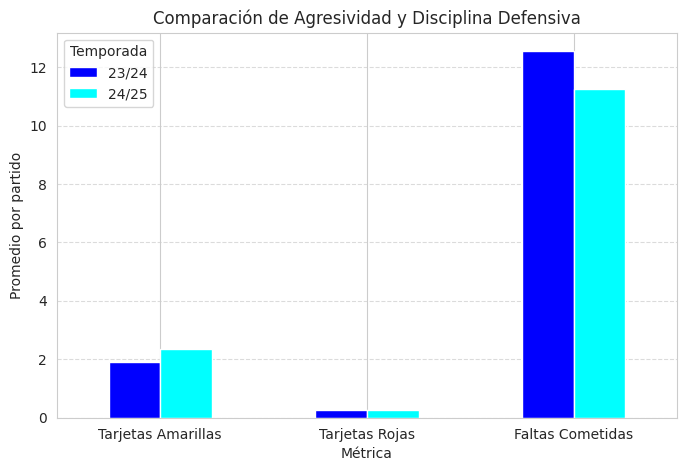

In [145]:
# Seleccionar columnas relevantes
cols = ['ta', 'tr', 'fls']  # Tarjetas amarillas, rojas y faltas

defensive_2324 = celta_23_24[cols].mean()
defensive_2425 = celta_24_25[cols].mean()

defensive_df = pd.DataFrame({
    'Métrica': ['Tarjetas Amarillas', 'Tarjetas Rojas', 'Faltas Cometidas'],
    '23/24': defensive_2324.values,
    '24/25': defensive_2425.values
})

# Graficar
fig, ax = plt.subplots(figsize=(8, 5))
defensive_df.plot(x='Métrica', kind='bar', ax=ax, color=['blue', 'cyan'])
plt.title("Comparación de Agresividad y Disciplina Defensiva")
plt.xlabel("Métrica")
plt.ylabel("Promedio por partido")
plt.xticks(rotation=0)
plt.legend(title="Temporada")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

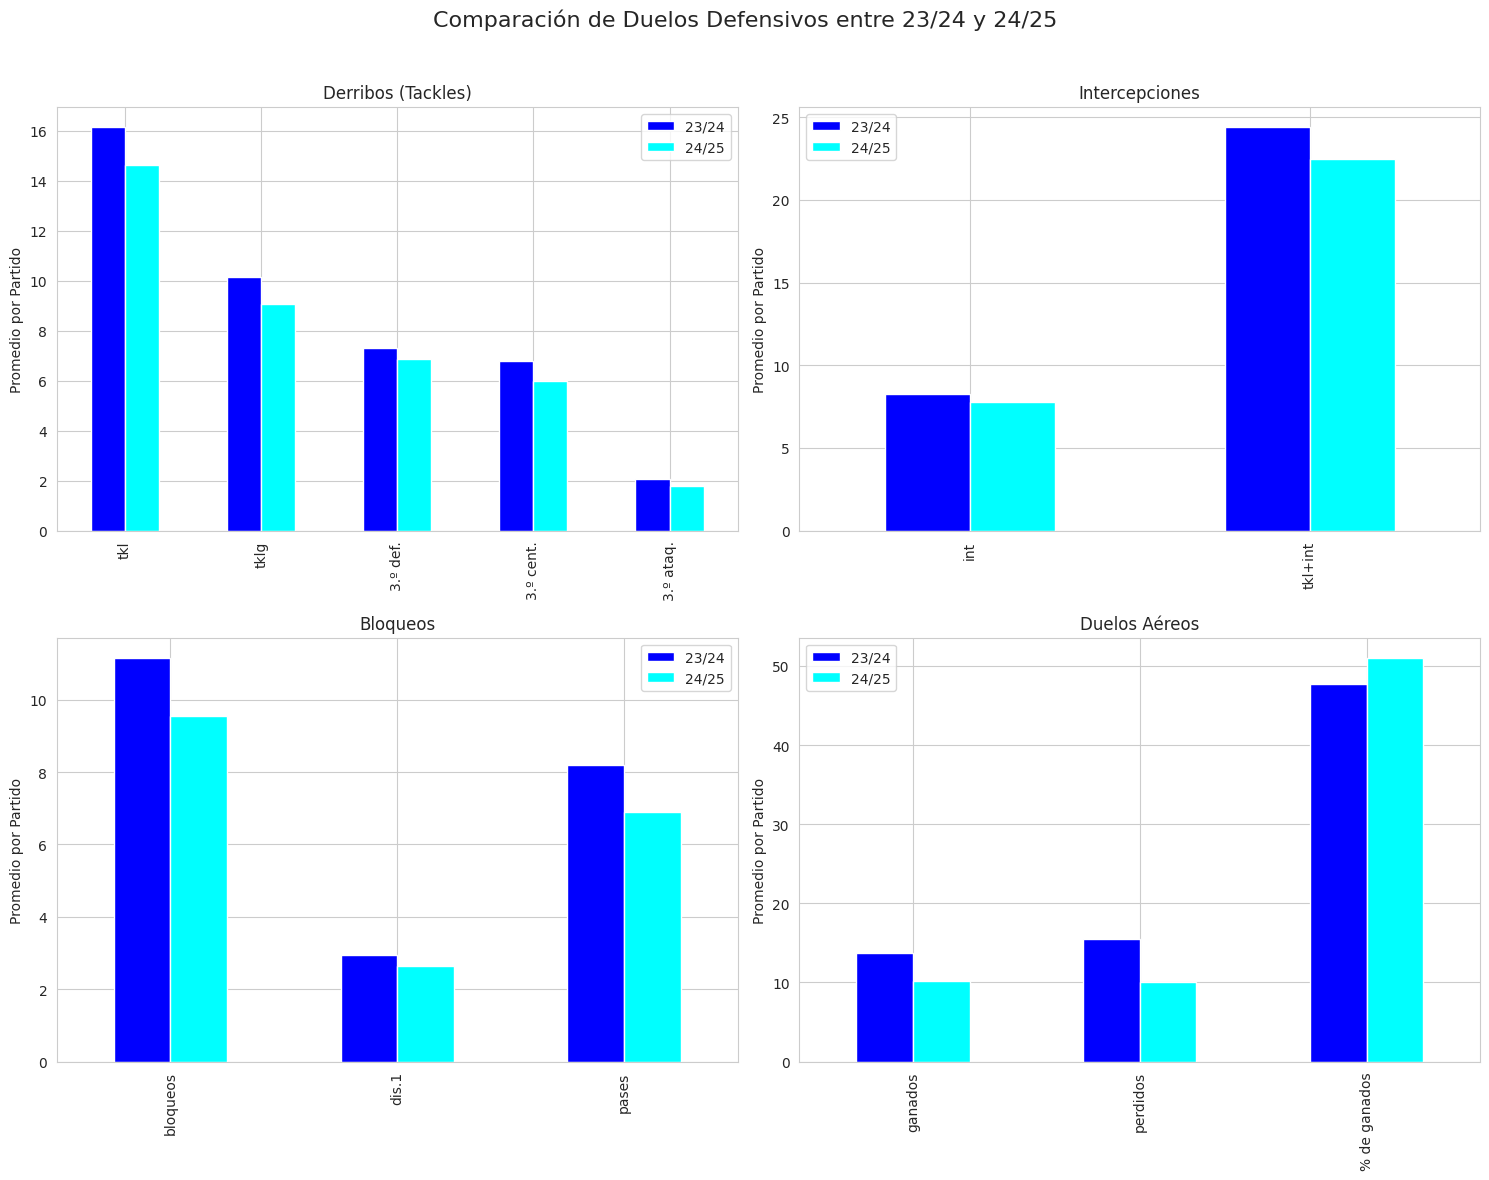

In [146]:
# Promediar las métricas defensivas por temporada
defensive_metrics = ['tkl', 'tklg', '3.º def.', '3.º cent.', '3.º ataq.', 'int', 'tkl+int', 'bloqueos', 'dis.1', 'pases', 'ganados', 'perdidos', '% de ganados']

defensive_23_24 = celta_23_24[defensive_metrics].mean()
defensive_24_25 = celta_24_25[defensive_metrics].mean()

# Crear un DataFrame comparativo
defensive_comparison = pd.DataFrame({'23/24': defensive_23_24, '24/25': defensive_24_25})

# Configurar estilo de gráficos
sns.set_style("whitegrid")
colors = ['blue', 'cyan']

# Crear gráficos comparativos
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Comparación de Duelos Defensivos entre 23/24 y 24/25", fontsize=16)

# Derribos (Tackles)
defensive_comparison.loc[['tkl', 'tklg', '3.º def.', '3.º cent.', '3.º ataq.']].plot(kind='bar', ax=axes[0,0], color=colors)
axes[0,0].set_title("Derribos (Tackles)")
axes[0,0].set_ylabel("Promedio por Partido")

# Intercepciones
defensive_comparison.loc[['int', 'tkl+int']].plot(kind='bar', ax=axes[0,1], color=colors)
axes[0,1].set_title("Intercepciones")
axes[0,1].set_ylabel("Promedio por Partido")

# Bloqueos
defensive_comparison.loc[['bloqueos', 'dis.1', 'pases']].plot(kind='bar', ax=axes[1,0], color=colors)
axes[1,0].set_title("Bloqueos")
axes[1,0].set_ylabel("Promedio por Partido")

# Duelos Aéreos
defensive_comparison.loc[['ganados', 'perdidos', '% de ganados']].plot(kind='bar', ax=axes[1,1], color=colors)
axes[1,1].set_title("Duelos Aéreos")
axes[1,1].set_ylabel("Promedio por Partido")

plt.legend(["23/24", "24/25"])
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

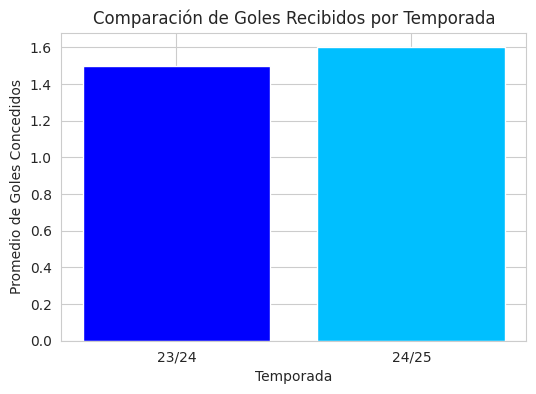

Promedio de goles recibidos en 23/24: 1.50
Promedio de goles recibidos en 24/25: 1.60


In [147]:
# Calcular promedios de goles concedidos
promedio_gc_2324 = celta_23_24['gc'].mean()
promedio_gc_2425 = celta_24_25['gc'].mean()

# Crear un gráfico de barras
plt.figure(figsize=(6, 4))
plt.bar(['23/24', '24/25'], [promedio_gc_2324, promedio_gc_2425], color=['blue', 'deepskyblue'])
plt.xlabel("Temporada")
plt.ylabel("Promedio de Goles Concedidos")
plt.title("Comparación de Goles Recibidos por Temporada")
plt.show()

# Mostrar resultados
print(f"Promedio de goles recibidos en 23/24: {promedio_gc_2324:.2f}")
print(f"Promedio de goles recibidos en 24/25: {promedio_gc_2425:.2f}")


📊 Correlación Posesión - Goles en Contra en 23/24: -0.07
📊 Correlación Posesión - Goles en Contra en 24/25: 0.41


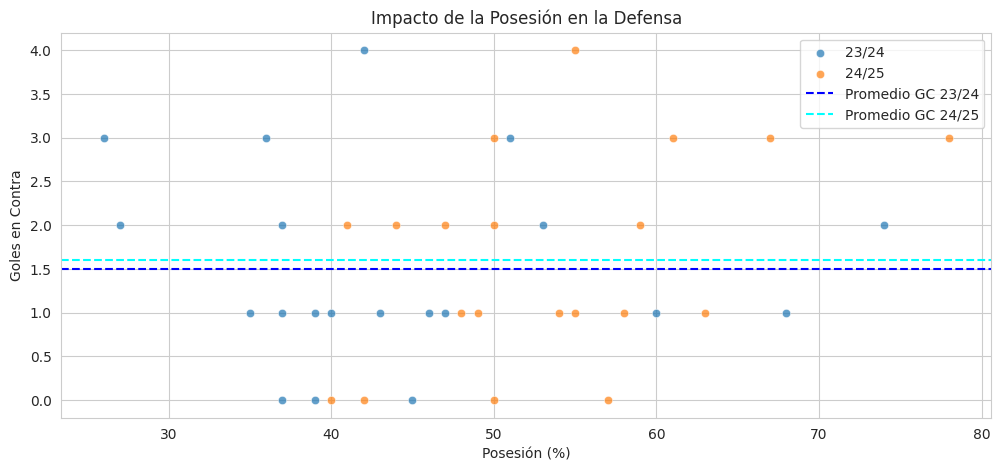

In [148]:
# Impacto de la posesión en la defensa
correlacion_23_24 = celta_23_24["pos."] .corr(celta_23_24["gc"])
correlacion_24_25 = celta_24_25["pos."] .corr(celta_24_25["gc"])

print(f"📊 Correlación Posesión - Goles en Contra en 23/24: {correlacion_23_24:.2f}")
print(f"📊 Correlación Posesión - Goles en Contra en 24/25: {correlacion_24_25:.2f}")

# Gráfico de dispersión posesión vs goles en contra
plt.figure(figsize=(12, 5))
sns.scatterplot(data=celta_23_24, x="pos.", y="gc", label="23/24", alpha=0.7)
sns.scatterplot(data=celta_24_25, x="pos.", y="gc", label="24/25", alpha=0.7)
plt.axhline(y=celta_23_24["gc"].mean(), color="blue", linestyle="dashed", label="Promedio GC 23/24")
plt.axhline(y=celta_24_25["gc"].mean(), color="cyan", linestyle="dashed", label="Promedio GC 24/25")
plt.xlabel("Posesión (%)")
plt.ylabel("Goles en Contra")
plt.title("Impacto de la Posesión en la Defensa")
plt.legend()
plt.show()


In [149]:
casa_23_24 = celta_23_24[celta_23_24["sedes"].str.lower() == "local"]
fuera_23_24 = celta_23_24[celta_23_24["sedes"].str.lower() == "visitante"]

casa_24_25 = celta_24_25[celta_24_25["sedes"].str.lower() == "local"]
fuera_24_25 = celta_24_25[celta_24_25["sedes"].str.lower() == "visitante"]

In [150]:
print(f"Partidos en casa 23/24: {len(casa_23_24)}, fuera: {len(fuera_23_24)}")
print(f"Partidos en casa 24/25: {len(casa_24_25)}, fuera: {len(fuera_24_25)}")

Partidos en casa 23/24: 10, fuera: 10
Partidos en casa 24/25: 11, fuera: 9


In [151]:
promedio_gc_casa_23_24 = casa_23_24["gc"].mean()
promedio_gc_fuera_23_24 = fuera_23_24["gc"].mean()

promedio_gc_casa_24_25 = casa_24_25["gc"].mean()
promedio_gc_fuera_24_25 = fuera_24_25["gc"].mean()

print(f"📊 Goles en Contra Promedio en Casa vs Fuera:")
print(f"Temporada 23/24 - Casa: {promedio_gc_casa_23_24:.2f} | Fuera: {promedio_gc_fuera_23_24:.2f}")
print(f"Temporada 24/25 - Casa: {promedio_gc_casa_24_25:.2f} | Fuera: {promedio_gc_fuera_24_25:.2f}")

📊 Goles en Contra Promedio en Casa vs Fuera:
Temporada 23/24 - Casa: 1.30 | Fuera: 1.70
Temporada 24/25 - Casa: 1.00 | Fuera: 2.33


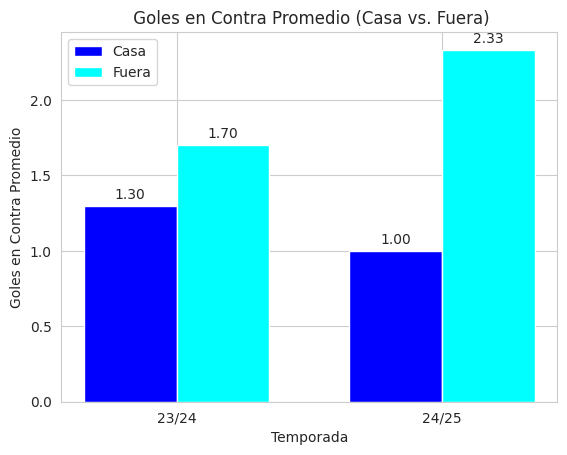

In [152]:
# Datos de los goles en contra promedio
gc_casa = [promedio_gc_casa_23_24, promedio_gc_casa_24_25]
gc_fuera = [promedio_gc_fuera_23_24, promedio_gc_fuera_24_25]
temporadas = ["23/24", "24/25"]

# Configuración del gráfico
x = np.arange(len(temporadas))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, gc_casa, width, label='Casa', color='blue')
rects2 = ax.bar(x + width/2, gc_fuera, width, label='Fuera', color='cyan')

# Etiquetas y título
ax.set_xlabel("Temporada")
ax.set_ylabel("Goles en Contra Promedio")
ax.set_title(" Goles en Contra Promedio (Casa vs. Fuera)")
ax.set_xticks(x)
ax.set_xticklabels(temporadas)
ax.legend()

# Mostrar valores en las barras
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

# Mostrar el gráfico
plt.show()

In [153]:
# Renombrar la columna mal escrita
celta_23_24.rename(columns={"res\nultado": "resultado"}, inplace=True)
celta_24_25.rename(columns={"Resultado": "resultado"}, inplace=True)

In [154]:
# Verificar que se ha renombrado correctamente
print(celta_23_24.columns)
print(celta_24_25.columns)

Index([       'fecha',         'hora',      'jornada',          'día',
              'sedes',    'resultado',           'gf',           'gc',
         'adversario',         'pos.',   'asistencia',      'capitán',
          'formación',      'árbitro',           'ta',           'tr',
        '2a amarilla',          'fls',           'fr',           'pa',
               'gls.',          'dis',          'dap',      '% de tt',
                'g/t',     'g/talarc',         'dist',           'fk',
                 'tp',        'tpint',           'xg',         'npxg',
            'npxg/sh',         'g-xg',      'np:g-xg',          'cmp',
               'int.',        '% cmp',   'dist. tot.',   'dist. prg.',
              'cmp.1',       'int..1',      '% cmp.1',        'cmp.2',
             'int..2',      '% cmp.2',        'cmp.3',       'int..3',
            '% cmp.3',          'ass',          'xag',           'xa',
                 'pc',            nan,          'ppa',         'crap',
      

In [155]:
# Convertimos los valores a mayúsculas por si hay inconsistencias
celta_23_24["resultado"] = celta_23_24["resultado"].str.upper()
celta_24_25["resultado"] = celta_24_25["resultado"].str.upper()

# Verificamos los valores únicos
print(celta_23_24["resultado"].unique())
print(celta_24_25["resultado"].unique())

['D' 'E' 'V']
['V' 'D' 'E']


In [156]:
# Cargar el archivo asegurando que las columnas de texto se lean correctamente
celta_23_24 = pd.read_excel("/content/drive/MyDrive/TFM/DATOS CONJUNTOS CELTA TITULO J20.xlsx", sheet_name="CELTA 23-24", dtype={"Día": str})
celta_24_25 = pd.read_excel("/content/drive/MyDrive/TFM/DATOS CONJUNTOS CELTA TITULO J20.xlsx", sheet_name="CELTA 24-25", dtype={"Día": str})

# Ver los primeros valores para comprobar que "día" está bien cargado
print(celta_23_24["Día"].head())
print(celta_24_25["Día"].head())


0    Dom
1    Sáb
2    Vie
3    Vie
4    Sáb
Name: Día, dtype: object
0    Vie
1    Vie
2    Lun
3    Dom
4    Dom
Name: Día, dtype: object


In [157]:
# Definir el orden correcto de los días de la semana
orden_dias = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]

In [158]:
print(celta_23_24.columns)
print(celta_24_25.columns)


Index([            'Fecha',              'Hora',           'Jornada',
                     'Día',             'Sedes',       'Res\nultado',
                      'GF',                'GC',        'Adversario',
                    'Pos.',        'Asistencia',           'Capitán',
               'Formación',           'Árbitro',                'TA',
                      'TR',       '2a amarilla',               'Fls',
                      'FR',                'PA',              'Gls.',
                     'Dis',               'DaP',           '% de TT',
                     'G/T',          'G/TalArc',              'Dist',
                      'FK',                'TP',             'TPint',
                      'xG',              'npxG',           'npxG/Sh',
                    'G-xG',           'np:G-xG',               'Cmp',
                    'Int.',             '% Cmp',        'Dist. tot.',
              'Dist. prg.',             'Cmp.1',            'Int..1',
                 '% 

In [159]:
celta_23_24.rename(columns={"Res\nultado": "resultado"}, inplace=True)
celta_24_25.rename(columns={"Resultado": "resultado"}, inplace=True)

In [160]:
print(celta_23_24[["Día", "resultado"]].head())
print(celta_24_25[["Día", "resultado"]].head())
print(celta_23_24["Día"].unique())
print(celta_24_25["Día"].unique())
print(celta_23_24["resultado"].unique())
print(celta_24_25["resultado"].unique())


   Día resultado
0  Dom         D
1  Sáb         E
2  Vie         D
3  Vie         V
4  Sáb         D
   Día resultado
0  Vie         V
1  Vie         V
2  Lun         D
3  Dom         D
4  Dom         V
['Dom' 'Sáb' 'Vie' 'Jue' 'Lun' 'Mié']
['Vie' 'Lun' 'Dom' 'Jue' 'Sáb']
['D' 'E' 'V']
['V' 'D' 'E']


In [161]:
# Convertir "Día" a minúsculas para uniformidad
celta_23_24["Día"] = celta_23_24["Día"].str.lower()
celta_24_25["Día"] = celta_24_25["Día"].str.lower()

# Normalizar los nombres de los días (por si hay diferencias)
dias_correccion = {"lun": "lun", "mar": "mar", "mié": "mié", "mie": "mié",
                   "jue": "jue", "vie": "vie", "sáb": "sáb", "sab": "sáb", "dom": "dom"}

celta_23_24["Día"] = celta_23_24["Día"].map(dias_correccion)
celta_24_25["Día"] = celta_24_25["Día"].map(dias_correccion)


In [162]:
print(celta_23_24["Día"].unique())
print(celta_24_25["Día"].unique())

['dom' 'sáb' 'vie' 'jue' 'lun' 'mié']
['vie' 'lun' 'dom' 'jue' 'sáb']


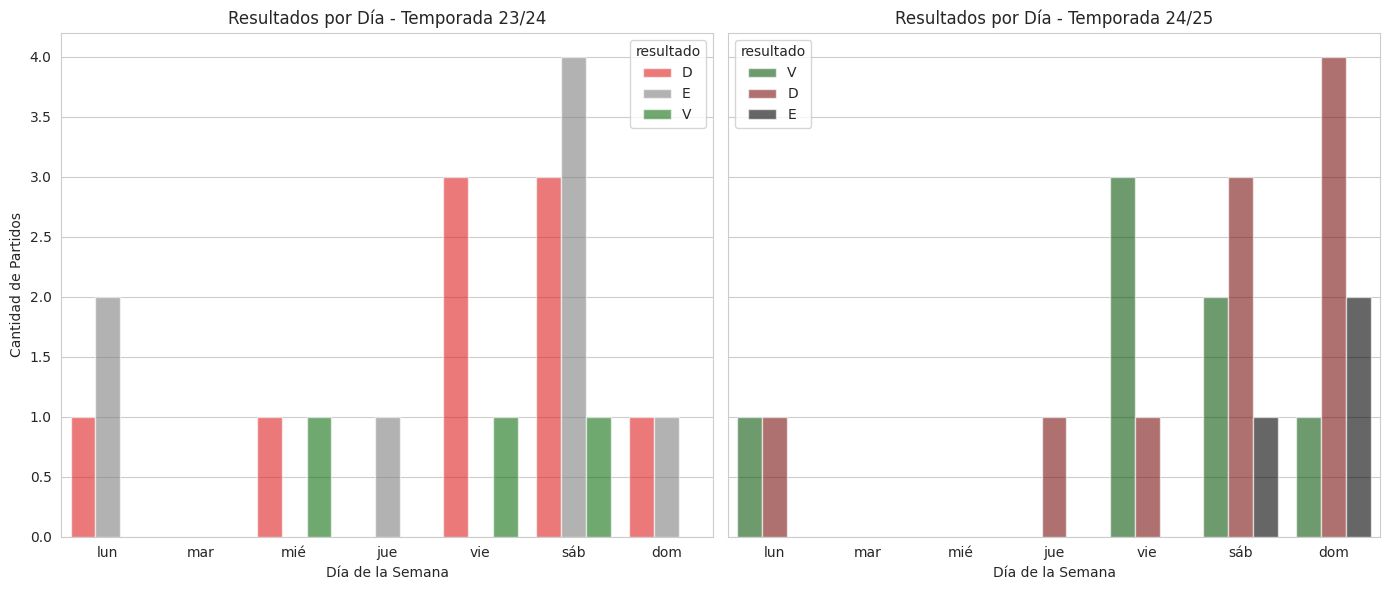

In [163]:
# Definir el orden correcto de los días
orden_dias = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]

# Crear la figura con subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Graficar temporada 23/24
sns.countplot(data=celta_23_24, x="Día", hue="resultado",
              order=orden_dias,
              palette={"V": "green", "E": "gray", "D": "red"},
              alpha=0.6, ax=axes[0])
axes[0].set_title("Resultados por Día - Temporada 23/24")

# Graficar temporada 24/25
sns.countplot(data=celta_24_25, x="Día", hue="resultado",
              order=orden_dias,
              palette={"V": "darkgreen", "E": "black", "D": "darkred"},
              alpha=0.6, ax=axes[1])
axes[1].set_title("Resultados por Día - Temporada 24/25")

# Configurar etiquetas
for ax in axes:
    ax.set_xlabel("Día de la Semana")
    ax.set_ylabel("Cantidad de Partidos")

# Ajustar diseño
plt.tight_layout()
plt.show()

In [164]:
print(celta_23_24["Hora"].head())
print(celta_24_25["Hora"].head())


0    17:00:00
1    17:00:00
2    21:30:00
3    22:00:00
4    18:30:00
Name: Hora, dtype: object
0    19:00:00
1    19:00:00
2    21:30:00
3    17:00:00
4    14:00:00
Name: Hora, dtype: object


In [165]:
# Función para convertir la hora a formato decimal
def convertir_hora(hora):
    if isinstance(hora, str):  # Si es texto, hay que procesarlo
        h, m, _ = map(int, hora.split(":"))  # Extraer horas y minutos
        return h + m / 60
    elif isinstance(hora, pd._libs.tslibs.timestamps.Timestamp):  # Si es datetime
        return hora.hour + hora.minute / 60
    elif isinstance(hora, datetime.time):  # Si ya es un objeto time
        return hora.hour + hora.minute / 60
    return None  # Si hay valores nulos

# Aplicar la conversión a ambas temporadas
celta_23_24["Hora_Num"] = celta_23_24["Hora"].apply(convertir_hora)
celta_24_25["Hora_Num"] = celta_24_25["Hora"].apply(convertir_hora)

# Verificar que se haya convertido correctamente
print(celta_23_24[["Hora", "Hora_Num"]].head())
print(celta_24_25[["Hora", "Hora_Num"]].head())

       Hora  Hora_Num
0  17:00:00      17.0
1  17:00:00      17.0
2  21:30:00      21.5
3  22:00:00      22.0
4  18:30:00      18.5
       Hora  Hora_Num
0  19:00:00      19.0
1  19:00:00      19.0
2  21:30:00      21.5
3  17:00:00      17.0
4  14:00:00      14.0


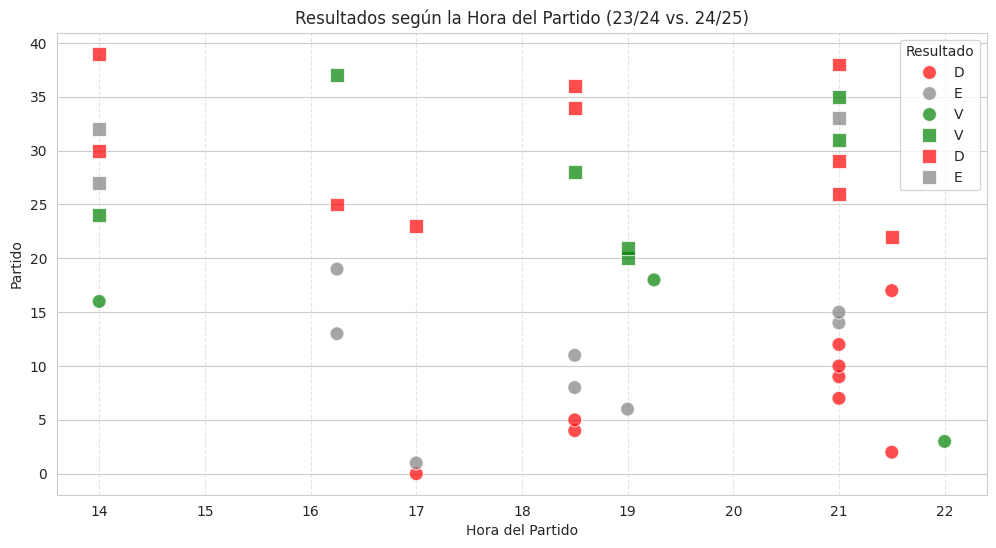

In [166]:
# Definir el mapeo de colores para los resultados
colores = {"V": "green", "E": "gray", "D": "red"}

plt.figure(figsize=(12, 6))

# Agregar una columna 'Partido' que represente el índice del partido en cada temporada
celta_23_24 = celta_23_24.reset_index().rename(columns={"index": "Partido"})
celta_24_25 = celta_24_25.reset_index().rename(columns={"index": "Partido"})

# Graficar puntos para la temporada 23/24
sns.scatterplot(data=celta_23_24, x="Hora_Num", y="Partido",
                hue="resultado", palette=colores, s=100, alpha=0.7)

# Graficar puntos para la temporada 24/25 en un nivel diferente de "Partido" para evitar solapamientos
sns.scatterplot(data=celta_24_25, x="Hora_Num", y=celta_24_25["Partido"] + len(celta_23_24),
                hue="resultado", palette=colores, s=100, alpha=0.7, marker="s")

# Configurar etiquetas y título
plt.xlabel("Hora del Partido")
plt.ylabel("Partido")
plt.title("Resultados según la Hora del Partido (23/24 vs. 24/25)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend(title="Resultado")

# Mostrar gráfico
plt.show()


In [167]:
# Definir las franjas horarias
def categorizar_hora(hora):
    if hora < 17:
        return "Mediodía (14-17)"
    elif 17 <= hora < 19:
        return "Tarde (17-19)"
    else:
        return "Noche (19-22:30)"

# Aplicar la categorización a ambas temporadas
celta_23_24["Franja_Horaria"] = celta_23_24["Hora_Num"].apply(categorizar_hora)
celta_24_25["Franja_Horaria"] = celta_24_25["Hora_Num"].apply(categorizar_hora)

# Función para calcular los porcentajes de resultados en cada franja
def calcular_porcentajes(df):
    total_partidos = df.groupby("Franja_Horaria")["resultado"].count()
    porcentajes = df.groupby(["Franja_Horaria", "resultado"])["resultado"].count().unstack(fill_value=0)
    porcentajes = porcentajes.div(total_partidos, axis=0) * 100  # Convertir a porcentaje
    return porcentajes

# Calcular porcentajes para ambas temporadas
porcentajes_23_24 = calcular_porcentajes(celta_23_24)
porcentajes_24_25 = calcular_porcentajes(celta_24_25)

# Mostrar los resultados
porcentajes_23_24, porcentajes_24_25

(resultado                 D          E          V
 Franja_Horaria                                   
 Mediodía (14-17)   0.000000  66.666667  33.333333
 Noche (19-22:30)  54.545455  27.272727  18.181818
 Tarde (17-19)     50.000000  50.000000   0.000000,
 resultado                 D          E          V
 Franja_Horaria                                   
 Mediodía (14-17)  42.857143  28.571429  28.571429
 Noche (19-22:30)  44.444444  11.111111  44.444444
 Tarde (17-19)     75.000000   0.000000  25.000000)

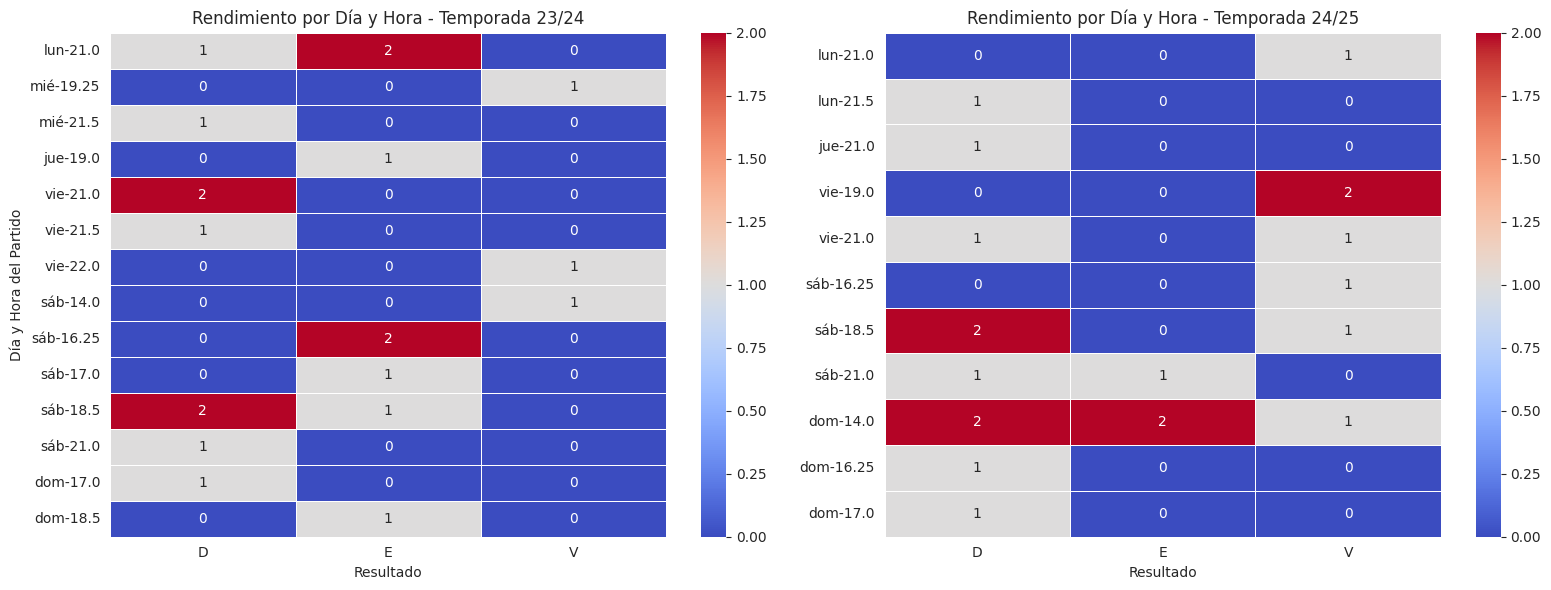

In [168]:
# Definir el orden correcto de los días
dias_ordenados = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]

# Función para generar la tabla cruzada para cada temporada
def generar_heatmap_data(df):
    heatmap_data = pd.crosstab(index=[df["Día"], df["Hora_Num"]], columns=df["resultado"])
    heatmap_data = heatmap_data.reindex(dias_ordenados, level=0)  # Ordenar por día de la semana
    return heatmap_data

# Generar datos para cada temporada
heatmap_23_24 = generar_heatmap_data(celta_23_24)
heatmap_24_25 = generar_heatmap_data(celta_24_25)

# Crear la figura y los subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Temporada 23/24
sns.heatmap(heatmap_23_24, annot=True, fmt="d", cmap="coolwarm", linewidths=0.5, ax=axes[0])
axes[0].set_title("Rendimiento por Día y Hora - Temporada 23/24")
axes[0].set_xlabel("Resultado")
axes[0].set_ylabel("Día y Hora del Partido")

# Heatmap Temporada 24/25
sns.heatmap(heatmap_24_25, annot=True, fmt="d", cmap="coolwarm", linewidths=0.5, ax=axes[1])
axes[1].set_title("Rendimiento por Día y Hora - Temporada 24/25")
axes[1].set_xlabel("Resultado")
axes[1].set_ylabel("")

# Mostrar el gráfico
plt.tight_layout()
plt.show()

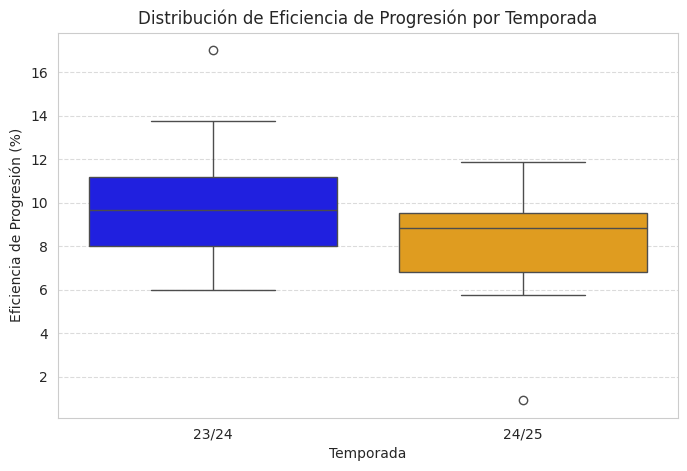

In [169]:
# Calcular eficiencia de progresión
celta_23_24['Eficiencia_Progresion'] = (celta_23_24['PrgP'] / celta_23_24['Cmp']) * 100
celta_24_25['Eficiencia_Progresion'] = (celta_24_25['PrgP'] / celta_24_25['Cmp']) * 100

# Crear un DataFrame combinado
celta_23_24['Temporada'] = '23/24'
celta_24_25['Temporada'] = '24/25'

data = pd.concat([celta_23_24[['Temporada', 'Eficiencia_Progresion']],
                  celta_24_25[['Temporada', 'Eficiencia_Progresion']]])

# Graficar la distribución de eficiencia de progresión en cada temporada
plt.figure(figsize=(8, 5))
sns.boxplot(x='Temporada', y='Eficiencia_Progresion', hue='Temporada', data=data, palette=['blue', 'orange'], legend=False)
plt.title('Distribución de Eficiencia de Progresión por Temporada')
plt.ylabel('Eficiencia de Progresión (%)')
plt.xlabel('Temporada')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()